### Imports

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

ModuleNotFoundError: No module named 'matplotlib'

## Clasificador Bayesiano Naive

In [3]:
# Calculate class probabilities P(C)
def calculate_class_probabilities(y):
    classes, counts = np.unique(y, return_counts=True)
    class_probabilities = counts / y.shape[0]
    return dict(zip(classes, class_probabilities))

# Calculate conditional probabilities P(A|C)
def calculate_conditional_probabilities(X, y):
    classes = np.unique(y)
    conditional_probabilities = {}

    for c in classes: # Para cada clase
        X_cls = X[y == c] # Obtener los ejemplos de la clase
        cls_count = X_cls.shape[0] # Número de ejemplos en la clase

        # Aplicar la corrección de Laplace: sumar 1 al numerador y el número de posibles valores al denominador
        conditional_attributes = (X_cls.sum(axis=0) + 1) / (cls_count + 2)
        
        # Almacenar las probabilidades condicionales
        conditional_probabilities[c] = conditional_attributes

    return conditional_probabilities

# Classify a new example
def classify(x, class_probabilities, conditional_probabilities):
    """
    Calcula las probabilidades de cada clase para un nuevo ejemplo.
    
    Args:
    - x: Array de características del nuevo ejemplo (binario).
    - class_probabilities: Diccionario con probabilidades de clase.
    - conditional_probabilities: Diccionario con probabilidades condicionales para cada clase.

    Returns:
    - dict: Probabilidades de cada clase.
    """
    probabilities = {}
    
    for c, prob_cls in class_probabilities.items():
        probability = prob_cls
        for i, value in enumerate(x):
            cond_prob = conditional_probabilities[c][i]
            if value == 1:
                probability *= cond_prob
            else:
                probability *= (1 - cond_prob)
        probabilities[c] = probability
    
    # Normalizar para obtener probabilidades
    total_prob = sum(probabilities.values())
    for c in probabilities:
        probabilities[c] /= total_prob
    
    return probabilities

# UK Clasification

Consideremos el siguiente vector de atributos binarios: `(scones, cerveza, whisky, avena, fútbol)`.

El vector `x = (1, 0, 1, 1, 0)` significa que se trata de una persona que le gustan los scones, no toma cerveza, le gusta el whisky y la avena pero no ve futbol.

En el archivo `PreferenciasBritanicos.xlsx` se encuentran las preferencias de 6 personas inglesas y 7 personas escocesas.

In [93]:
# Load the data
data = pd.read_excel('PreferenciasBritanicos.xlsx')

# Split the data into features (X) and the target class (y)
X = data.iloc[:, :-1].values  # All attributes except nationality
y = data.iloc[:, -1].values   # Nationality

In [94]:
# Get class probabilities and conditional probabilities
class_probabilities = calculate_class_probabilities(y)
conditional_probabilities = calculate_conditional_probabilities(X, y)

# b) Classify example x1 = (1, 0, 1, 1, 0)
x1 = np.array([1, 0, 1, 1, 0])
result_x1 = classify(x1, class_probabilities, conditional_probabilities)

# c) Classify example x2 = (0, 1, 1, 0, 1)
x2 = np.array([0, 1, 1, 0, 1])
result_x2 = classify(x2, class_probabilities, conditional_probabilities)

print(f"The example x1 = {x1} is classified as: {result_x1}")
print(f"The example x2 = {x2} is classified as: {result_x2}")

The example x1 = [1 0 1 1 0] is classified as: {'E': 0.7639887181632509, 'I': 0.2360112818367491}
The example x2 = [0 1 1 0 1] is classified as: {'E': 0.1682731809922672, 'I': 0.8317268190077327}


# Text Clasification

Implementar un clasificador de texto utilizando el clasificador ingenuo de Bayes. Utilizar el conjunto de datos `NoticiasArgentinas.xlsx` para clasificar cada noticia según su tipo.

In [4]:
# Leer el archivo Excel
df = pd.read_excel('NoticiasArgentinas.xlsx')

## Funciones de preprocesamiento

Funciones para preprocesar los titulares.
Para lematizar, eliminar stop words, categorizar palabras y pasar a binario.

In [5]:
class PhoneticAlgorithmsES():
    @staticmethod
    def string_at(string, start, string_length, lista):
        if ((start < 0) or (start >= len(string))):
            return 0
        for expr in lista:
            if string.find(expr, start, start + string_length) != -1:
                return 1
        return 0

    @staticmethod
    def substr(string, start, string_length):
        v = string[start:start + string_length]
        return v

    @staticmethod
    def is_vowel(string, pos):
        return string[pos] in ['A', 'E', 'I', 'O', 'U']

    @staticmethod
    def strtr(st):
        if st:
            st = st.replace('á', 'A')
            st = st.replace('ch', 'X')
            st = st.replace('ç', 'S')
            st = st.replace('é', 'E')
            st = st.replace('í', 'I')
            st = st.replace('ó', 'O')
            st = st.replace('ú', 'U')
            st = st.replace('ñ', 'NY')
            st = st.replace('gü', 'W')
            st = st.replace('ü', 'U')
            st = st.replace('b', 'V')
            # st=st.replace('z','S')
            st = st.replace('ll', 'Y')
            return st
        else:
            return ''

    def __init__(self):
        pass

    def metaphone(self, string):

        # initialize metaphone key string
        meta_key = ""
        # set maximum metaphone key size
        key_length = 6
        # set current position to the beginning
        current_pos = 0
        # get string  length
        string_length = len(string)
        # set to  the end of the string
        end_of_string_pos = string_length - 1
        original_string = string + "    "
        # Let's replace some spanish characters  easily confused
        original_string = self.strtr(original_string.lower())
        # convert string to uppercase
        original_string = original_string.upper()

        # main loop
        while (len(meta_key) < key_length):

            # break out of the loop if greater or equal than the length
            if (current_pos >= len(original_string)):
                break
            # get character from the string
            current_char = original_string[current_pos]

            # if it is a vowel, and it is at the begining of the string,
            # set it as part of the meta key
            if (self.is_vowel(original_string, current_pos) and (current_pos == 0)):

                meta_key += current_char
                current_pos += 1

            # Let's check for consonants  that have a single sound
            # or already have been replaced  because they share the same
            # sound like 'B' for 'V' and 'S' for 'Z'
            else:
                if (self.string_at(original_string, current_pos, 1, ['D', 'F', 'J', 'K', 'M', 'N', 'P', 'T', 'V', 'L', 'Y'])):
                    meta_key += current_char

                # increment by two if a repeated letter is found
                    if (self.substr(original_string, current_pos + 1, 1) == current_char):
                        current_pos += 2
                    else:  # increment only by one
                        current_pos += 1

                else:  # check consonants with similar confusing sounds
                    if current_char == 'C':
                        # special case 'macho', chato,etc.
                        # if (self.substr(original_string, current_pos + 1,1)== 'H'):
                        # current_pos += 2

                        # special case 'acción', 'reacción',etc.
                        if (self.substr(original_string, current_pos + 1, 1) == 'C'):
                            meta_key += 'X'
                            current_pos += 2

                           # special case 'cesar', 'cien', 'cid', 'conciencia'
                        elif (self.string_at(original_string, current_pos, 2, ['CE', 'CI'])):
                            meta_key += 'Z'
                            current_pos += 2

                        else:
                            meta_key += 'K'
                            current_pos += 1

                    elif current_char == 'G':
                       # special case 'gente', 'ecologia',etc
                        if (self.string_at(original_string, current_pos, 2, ['GE', 'GI'])):
                            meta_key += 'J'
                            current_pos += 2
                        else:
                            meta_key += 'G'
                            current_pos += 1

                # since the letter 'h' is silent in spanish,
                # let's set the meta key to the vowel after the letter 'h'
                    elif current_char == 'H':
                        if (self.is_vowel(original_string, current_pos + 1)):
                            meta_key += original_string[current_pos + 1]
                            current_pos += 2

                        else:
                            meta_key += 'H'
                            current_pos += 1

                    elif current_char == 'Q':
                        if (self.substr(original_string, current_pos + 1, 1) == 'U'):
                            current_pos += 2
                        else:

                            current_pos += 1

                        meta_key += 'K'

                    elif current_char == 'W':
                        # if (current_pos == 0):
                        # meta_key   += 'V'
                        # current_pos += 2
                        meta_key += 'U'
                        current_pos += 1

                    # perro, arrebato, cara
                    elif current_char == 'R':
                        current_pos += 1
                        meta_key += 'R'

                    # spain
                    elif current_char == 'S':
                        if (not self.is_vowel(original_string, current_pos + 1)) and (current_pos == 0):
                            meta_key += 'ES'
                            current_pos += 1
                        else:
                            current_pos += 1
                            meta_key += 'S'

                    # zapato
                    elif current_char == 'Z':
                        current_pos += 1
                        meta_key += 'Z'

                    elif current_char == 'X':
                        # some mexican spanish words like'Xochimilco','xochitl'
                        # if (current_pos == 0):
                        ##
                        # meta_key   += 'S'
                        # current_pos += 2
                        ##
                        # else:
                        if (not self.is_vowel(original_string, current_pos + 1)) and len(string) > 1 and (current_pos == 0):
                            meta_key += 'EX'
                            current_pos += 1
                        else:
                            meta_key += 'X'
                            current_pos += 1

                    else:
                        current_pos += 1

                 # trim any blank characters
        meta_key = meta_key.strip()

        # return the final meta key string
        return meta_key


In [6]:
import Levenshtein
import spacy

# Cargar el modelo de spaCy para español
nlp = spacy.load("es_core_news_lg")

def clean_text(text):
    # Reemplaza comillas y otros caracteres especiales por espacios
    text = re.sub(r'[^\w\s]', ' ', text)
    return text

# Función para lematización y eliminación de stop words
def lemmatize(text):
    text = clean_text(text)
    doc = nlp(text.lower())
    lemmatized = []
    
    for token in doc:
        if not token.is_stop and token.is_alpha:
            lemmatized.append(token.lower_)  #lower solo hace minuscula / lemma hace lematized
    
    return " ".join(lemmatized)

# Función para unificar palabras similares utilizando la distancia de Levenshtein
def unify_similar_words(vocab, threshold):
    unified_vocab = {}
    
    for word in vocab:
        found = False
        for unified_word in unified_vocab:
            if Levenshtein.distance(word, unified_word) < threshold:
                unified_vocab[unified_word].append(word)
                found = True
                break
        
        if not found:
            unified_vocab[word] = [word]
    
    return unified_vocab

# Función para unificar palabras utilizando Metaphone
def unify_phonetic_words(vocab, pa):
    metaphone_dict = {}
    
    for word in vocab:
        metaphone_key = pa.metaphone(word)
        if metaphone_key in metaphone_dict:
            metaphone_dict[metaphone_key].append(word)
        else:
            metaphone_dict[metaphone_key] = [word]
    
    unified_vocab = {}
    
    for words in metaphone_dict.values():
        main_word = max(words, key=len)  # Selecciona la palabra más larga como representante
        unified_vocab[main_word] = words
    
    # vocab: [abuela, abuelo, casa, caza, perro, carro]
    # unified_vocab: {abuela: [abuela, abuelo], ...}
    return unified_vocab

# Función para categorizar palabras
def categorize_words(text):
    categories = {
    # **Enfermedades**
    'enfermedad': [
        'diabetes', 'cáncer', 'gripe', 'covid', 'asma', 'alergia', 'presión', 'colesterol', 'obesidad',
        'tuberculosis', 'hepatitis', 'influenza', 'artritis', 'epilepsia', 'migraña', 'sida', 'neumonía',
        'hemorragia', 'osteoporosis', 'esclerosis', 'fibromialgia', 'autismo', 'autoinmune', 'aneurisma',
        'encefalitis', 'sífilis', 'herpes', 'gastritis', 'ulcera', 'insuficiencia', 'hipertensión',
        'pneumonía', 'tifoidea', 'malaria', 'chagas', 'leptospirosis', 'brote', 'triquinosis'
    ],
    # **Tratamientos y Medicamentos**
    'tratamiento': [
        'vacuna', 'antibiótico', 'antiviral', 'medicamento', 'cirugía', 'rehabilitación', 'quimioterapia',
        'radioterapia', 'fisioterapia', 'inmunoterapia', 'insulina', 'análisis', 'diagnóstico', 'prescripción',
        'antidepresivo', 'ansiolítico', 'sedante', 'analgésico', 'antiinflamatorio', 'antihistamínico',
        'antipirético', 'diurético', 'antifúngico', 'antiparasitario', 'vacunación', 'suplemento', 'crema',
        'pastilla', 'inyección', 'transfusión', 'plasma', 'analítica'
    ],
    # **Organizaciones y Establecimientos de Salud**
    'salud': [
        'hospital', 'clínica', 'centro', 'consultorio', 'laboratorio', 'farmacia', 'seguro', 'sala', 'urgencias',
        'medicina', 'cuerpo', 'salud', 'ministerio', 'instituto', 'fundación', 'albergue', 'sanatorio',
        'consultorio', 'departamento', 'asociación', 'banco de sangre', 'policlínico', 'SAME', 'PAMI', 'obra social', 'salud'
    ],
    # **Finanzas Personales**
    'finanza': [
        'inflación', 'crédito', 'deuda', 'ahorro', 'gasto', 'presupuesto', 'impuesto', 'salario', 'subsidio',
        'cheque', 'transferencia', 'interés', 'cuenta', 'pensión', 'inversión', 'ahorro', 'banco', 'recibo',
        'tarjeta', 'préstamo', 'ahorro', 'moneda', 'cambio', 'cuota', 'liquidación', 'subsidio', 'pago'
    ],
    # **Inversión y Economía**
    'inversión': [
        'bolsa', 'mercado', 'acciones', 'bonos', 'divisas', 'capital', 'rendimiento', 'cartera', 'renta',
        'fondo', 'dividendo', 'patrimonio', 'seguros', 'inversión', 'tasa', 'bursátil', 'cartera', 'derivados',
        'valor', 'capital', 'banco', 'broker', 'acciones', 'fondos', 'subasta', 'títulos', 'criptomoneda', 'bitcoin'
    ],
    'economía': [
        'inflación', 'recesión', 'crecimiento', 'PIB', 'déficit', 'superávit', 'subsidio', 'impuestos',
        'ingresos', 'gasto', 'presupuesto', 'mercado', 'finanzas', 'economía', 'banco', 'moneda', 'interés',
        'comercio', 'inversión', 'exportación', 'importación', 'acuerdo', 'ajuste', 'crisis', 'dólar', 'devaluación',
        'exportación', 'importación', 'deuda', 'tasa de interés', 'acuerdo', 'subsidios', 'financiamiento'
    ],
    # **Tecnología y Ciencia**
    'tecnología': [
        'software', 'hardware', 'app', 'sistema', 'red', 'internet', 'datos', 'nube', 'algoritmo',
        'base', 'plataforma', 'código', 'digital', 'programa', 'computadora', 'plataforma', 'servicio',
        'tecnología', 'procesador', 'memoria', 'redes', 'seguridad', 'base de datos', 'sistema operativo',
        'inteligencia', 'ciberseguridad', 'redes sociales', 'cloud', 'automatización', 'IoT', 'smartphone'
    ],
    'innovación': [
        'blockchain', 'drones', 'biotecnología', 'realidad', 'virtual', '5G', 'nano', 'ciberseguridad',
        'impresión', 'robotica', 'IA', 'machine', 'cuántica', 'wearable', 'sensores', 'automatización',
        'computación', 'virtualización', 'algoritmo', 'inteligencia', 'machine',
        'reconocimiento', 'biometría', 'drone', 'blockchain', 'smart'
    ],
    'ciencia': [
        'física', 'química', 'biología', 'astronomía', 'geología', 'ecología', 'matemáticas', 'genética',
        'neurociencia', 'biotecnología', 'medicina', 'científico', 'experimento', 'teoría', 'investigación',
        'laboratorio', 'datos', 'hipótesis', 'análisis', 'cálculo', 'estadística', 'modelo', 'descubrimiento',
        'experimento', 'teórico', 'científico', 'observación', 'hipótesis', 'prueba', 'estudio'
    ],
    # **Deportes**
    'deporte': [
        'fútbol', 'baloncesto', 'tenis', 'natación', 'ciclismo', 'atletismo', 'golf', 'rugby', 'boxeo',
        'voleibol', 'deportes', 'competencia', 'medalla', 'partido', 'torneo', 'liga', 'entrenamiento',
        'maratón', 'esquí', 'surf', 'hockey', 'escalada', 'karate', 'judo', 'taekwondo', 'wrestling',
        'fútbol', 'básquet', 'fútbol sala', 'polo', 'patinaje', 'vela', 'yachting', 'automovilismo',
        'motociclismo', 'escalada', 'rugby', 'gimnasia', 'hockey', 'handball'
    ],
    'atleta': [
        'jugador', 'entrenador', 'deportista', 'atleta', 'competidor', 'maratonista', 'boxeador', 'nadador',
        'futbolista', 'baloncestista', 'ciclista', 'tenista', 'golfista', 'rugby', 'voleibolista', 'esquiador',
        'atleta', 'jugador', 'deportista', 'competidor', 'corredor', 'nadador', 'esquiador', 'goleador'
    ],
    'equipo': [
        'club', 'equipo', 'selección', 'federación', 'asociación', 'liga', 'escudería', 'squad', 'plantel',
        'roster', 'formación', 'delegación', 'nacional', 'internacional', 'provincial', 'club', 'selección',
        'federación', 'asociación', 'equipo', 'escuadra', 'plantel'
    ],
    # **Entretenimiento y Cultura**
    'entretenimiento': [
        'cine', 'música', 'teatro', 'artista', 'festival', 'concierto', 'show', 'actor', 'directores',
        'película', 'serie', 'reparto', 'guion', 'producción', 'trama', 'evento', 'performer', 'drama',
        'documental', 'premio', 'escenario', 'audiencia', 'espectáculo', 'comedia', 'entrevista', 'festival',
        'presentador', 'animación', 'guion', 'banda', 'grupo'
    ],
    'cultura': [
        'arte', 'historia', 'literatura', 'arquitectura', 'museo', 'galería', 'exposición', 'costumbre',
        'folklore', 'ritual', 'etnografía', 'patrimonio', 'obra', 'autores', 'poesía', 'novela', 'ensayo',
        'libro', 'autor', 'narrativa', 'mito', 'leyenda', 'tradición', 'costumbre', 'música', 'teatro', 'arte',
        'culturas', 'pintura', 'escultura', 'danza', 'música', 'gastronomía', 'festividades', 'rituales'
    ],
    'comunicación': [
        'televisión', 'radio', 'prensa', 'revista', 'periódico', 'noticia', 'reportaje', 'entrevista',
        'noticiero', 'artículo', 'columna', 'canal', 'programa', 'documental', 'cadena', 'blog', 'podcast',
        'sección', 'redacción', 'comunicado', 'anuncio', 'informativo', 'emisión', 'noticiero', 'reportaje',
        'diario', 'revista', 'informativo', 'espectáculo', 'editorial', 'informativo', 'redes sociales'
    ],
    'artistas': [
        'actor', 'actriz', 'músico', 'director', 'productor', 'guionista', 'comediante', 'bailarín',
        'cantante', 'presentador', 'escritor', 'dramaturgo', 'pintor', 'escultor', 'fotógrafo', 'artista',
        'cineasta', 'intérprete', 'escenógrafo', 'coreógrafo', 'diseñador', 'fotógrafo', 'productor',
        'director', 'artista', 'músico', 'bailarín', 'compositor', 'guionista'
    ]
}
    for category, words in categories.items():
        for word in words:
            text = text.replace(word, category)
    return text

# Actualizar los titulares con las palabras unificadas
def unify_text(text, vocab):
    words = text.split()
    unified_text = []
    
    for word in words:
        for unified_word, variants in vocab.items():
            if word in variants:
                unified_text.append(unified_word)
                break
        else:
            unified_text.append(word)
    
    return " ".join(unified_text)

In [7]:
def preprocess_text_pipeline(dataset_train, dataset_test, use_lemmatize, levenshtein_threshold, use_metaphone, use_categorize):
    if use_lemmatize:
        dataset_train.loc[:, 'titular'] = dataset_train['titular'].apply(lambda x: lemmatize(x))
        dataset_test.loc[:, 'titular'] = dataset_test['titular'].apply(lambda x: lemmatize(x))
    
    # Obtener todas las palabras únicas en los titulares de entrenamiento
    vocab_train = set()
    for titular in dataset_train['titular']:
        words = re.split(r'\W+', titular)
        words = [word.lower() for word in words if word]
        vocab_train.update(words)
    
    # Obtener todas las palabras únicas en los titulares de prueba
    vocab_test = set()
    for titular in dataset_test['titular']:
        words = re.split(r'\W+', titular)
        words = [word.lower() for word in words if word]
        vocab_test.update(words)
        
    vocab_test = vocab_test - vocab_train  # Eliminar palabras que no estén en el conjunto de entrenamiento

    vocab_map = {}
    # Aplicar Levenshtein después de Metaphone
    if levenshtein_threshold > 0:
        vocab_map = unify_similar_words(vocab_train | vocab_test, threshold=levenshtein_threshold)
        vocab_train = vocab_map.keys() - unify_similar_words(vocab_test - vocab_train, threshold=levenshtein_threshold).keys()
        
    # Unificar palabras utilizando Metaphone
    if use_metaphone:
        pa = PhoneticAlgorithmsES()
        vocab_map = unify_phonetic_words(vocab_train | vocab_test, pa)
        vocab_train = vocab_map.keys() - unify_phonetic_words(vocab_test - vocab_train, pa).keys()

    # Actualizar los titulares con las palabras unificadas
    if vocab_map.keys():
        dataset_train.loc[:, 'titular'] = dataset_train['titular'].apply(lambda x: unify_text(x, vocab_map))
        dataset_test.loc[:, 'titular'] = dataset_test['titular'].apply(lambda x: unify_text(x, vocab_map))
    
    # Categorizar palabras después de la unificación
    if use_categorize:
        dataset_train.loc[:, 'titular'] = dataset_train['titular'].apply(categorize_words)
        dataset_test.loc[:, 'titular'] = dataset_test['titular'].apply(categorize_words)
        vocab_train = set(categorize_words(" ".join(vocab_train)).split())
    
    return sorted(list(vocab_train)), vocab_map

# Convertir los titulares en un array binario utilizando el vocabulario unificado
# vocab[hola] = 0, vocab[messi] = 1, vocab[jugador] = 2, vocab[el] = 3, vocab[es] = 5, vocab[mejor] = 7
# titular: messi es el mejor jugador
# vector_caracteristica = [0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, ...]
def text_to_binary_vector(text, vocab): 
    words = re.split(r'\W+', text)
    binary_vector = np.zeros(len(vocab), dtype=int)
    
    for word in words:
        if word in vocab:
            i = vocab.index(word)
            binary_vector[i] = 1
    
    return binary_vector

## Preparar datos de Train y de Test

### Test 1
Usando 80%-20% de las 4 categorías.

### Test 2
Usando 'Destacadas' como testeo.

In [8]:
categories_of_interest = ['Deportes', 'Ciencia y Tecnologia', 'Economia', 'Salud']
dataset = df[df['categoria'].isin(categories_of_interest)]


# ************* TEST 1 ************* # split dataset 80-20
#dataset_train, dataset_test = train_test_split(dataset, test_size=0.2, random_state=42)

# ************* TEST 2 ************* # use 'Destacadas' as test set
categories_of_test = ['Destacadas']
dataset_train, dataset_test = dataset, df[df['categoria'].isin(categories_of_test)]

vocab_train, vocab_map = preprocess_text_pipeline(
    dataset_train, dataset_test,
    use_lemmatize=False,       # Activar lematización
    levenshtein_threshold=0, # Activar Levenshtein
    use_metaphone=False,   # Activar Metaphone
    use_categorize=False       # Activar categorización
)

X_train = np.array([text_to_binary_vector(titular, vocab_train) for titular in dataset_train['titular']])
Y_train = dataset_train['categoria'].values

# ************* TEST 1 ************* # split dataset 80-20
# X_test = np.array([text_to_binary_vector(titular, vocab_train) for titular in dataset_test['titular']])
# Y_test = dataset_test['categoria'].values

# ************* TEST 2 ************* # use 'Destacadas' as test set
X_test = np.array([text_to_binary_vector(titular, list(vocab_train)) for titular in dataset_test['titular']])
Y_test = None # No hay etiquetas para el conjunto, no supervisado


In [80]:
print(len(vocab_train))
# print the key that has "river" in values in vocab_map
for key, value in vocab_map.items():
    if "venta" in value:
        print(key)

6874


In [90]:
# print the index of the words in "Superclasico River sacó a la venta más entradas para la final" in vocab_train
titular = "Diabetes tipo 1, la enfermedad crónica más frecuente en niños"
titular = lemmatize(titular)
words = re.split(r'\W+', titular)
words = [word.lower() for word in words if word]
for word in words:
    if word in vocab_train:
        i = vocab_train.index(word)
        print(f"Word: {word}, Index: {i}")
# check in vocab_map the key of the words in titular
for word in words:
    for key, value in vocab_map.items():
        if word in value:
            print(f"Word: {word}, Key: {key}")

Word: diabetes, Index: 1275
Word: enfermedad, Index: 1482
Word: crónico, Index: 1064
Word: frecuente, Index: 1782
Word: diabetes, Key: diabetes
Word: tipo, Key: tapia
Word: enfermedad, Key: enfermedad
Word: crónico, Key: crónico
Word: frecuente, Key: frecuente
Word: niño, Key: niña


## Entrenar el Clasificador Naive Bayes

Utilizamos las funciones `calculate_class_probabilities`, `calculate_conditional_probabilities`, y `classify` del ejemplo anterior para entrenar y probar nuestro modelo.

In [91]:
# Calcular las probabilidades de clase y las probabilidades condicionales
class_probabilities = calculate_class_probabilities(Y_train)
conditional_probabilities = calculate_conditional_probabilities(X_train, Y_train)

# Obtener las probabilidades predichas para cada clase
y_pred_prob = [classify(x, class_probabilities, conditional_probabilities) for x in X_test]

# Convertir las probabilidades predichas en etiquetas
y_pred = [max(prob.keys(), key=lambda k: prob[k]) for prob in y_pred_prob]

In [85]:
print(dataset_train['titular'].head())
print(sorted(vocab_train))

2403                      santa fe finanza octubre acumula
11732                                 síntomas andropausia
846                                      mejores celulares
1098                                     mejores celulares
5975     enigma agua intriga ciencias planeta tragando ...
Name: titular, dtype: object
['abajo', 'abandona', 'abandonan', 'abandonar', 'abastecimiento', 'abdominales', 'abe', 'abierta', 'abiertas', 'abierto', 'abogado', 'abogados', 'abordado', 'abortos', 'abra', 'abrazar', 'abrazo', 'abre', 'abren', 'abrieron', 'abril', 'abrir', 'abrió', 'absorber', 'absorbió', 'absorción', 'abuela', 'abuelo', 'abundancia', 'abusa', 'abusan', 'abuso', 'acaba', 'acaban', 'acabar', 'acalló', 'acceder', 'accesibilidad', 'acceso', 'accidente', 'acción', 'accord', 'aceite', 'acelera', 'acelerar', 'acelerará', 'acento', 'acepta', 'aceptan', 'acerca', 'acercarse', 'acercará', 'acercó', 'acevedo', 'aciencia', 'aclararon', 'aclaró', 'acné', 'acogerían', 'acomodan', 'acompañan', 

## Métricas

Test supervisado (Test 1)

Matriz de Confusión:
[[742   9   6   6]
 [  6 747  11   8]
 [ 22   3 732   7]
 [  2   4  11 765]]
Accuracy: 96.9166%
Precisión: 0.9692
Tasa de Verdaderos Positivos (Recall): 0.9692
F1-score: 0.9692


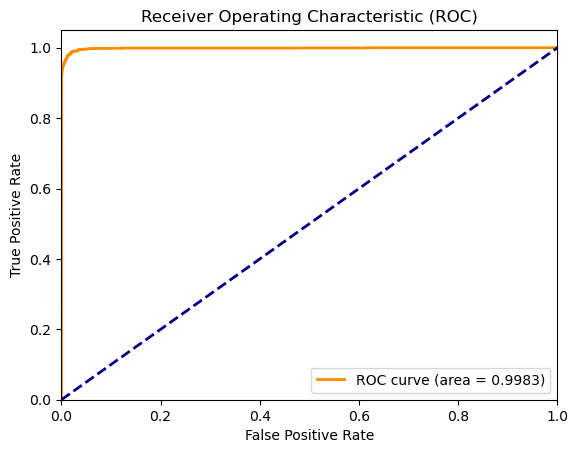

In [92]:
# ************* TEST 1 ************* # split dataset 80-20

# Convertir y_test y y_pred a formato binario para métricas
lb = LabelBinarizer()
lb.fit(Y_train)  # Ajustar el binarizador con las etiquetas de entrenamiento
y_test_bin = lb.transform(Y_test)
y_pred_bin = lb.transform(y_pred)

# Calcular la matriz de confusión
conf_matrix = confusion_matrix(y_test_bin.argmax(axis=1), y_pred_bin.argmax(axis=1))
print("Matriz de Confusión:")
print(conf_matrix)

# Calcular las medidas de evaluación
accuracy = accuracy_score(y_test_bin, y_pred_bin)
precision = precision_score(y_test_bin, y_pred_bin, average='weighted')
recall = recall_score(y_test_bin, y_pred_bin, average='weighted')
f1 = f1_score(y_test_bin, y_pred_bin, average='weighted')

print(f"Accuracy: {accuracy * 100:.4f}%")
print(f"Precisión: {precision:.4f}")
print(f"Tasa de Verdaderos Positivos (Recall): {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Calcular la curva ROC
y_test_bin_flat = y_test_bin.ravel()
y_pred_prob_flat = np.array([prob[c] for prob in y_pred_prob for c in lb.classes_])

fpr, tpr, _ = roc_curve(y_test_bin_flat, y_pred_prob_flat)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()


Dump Destacadas (Test 2)

In [ ]:
# ************* TEST 2 ************* # use 'Destacadas' as test set
# Dump X_test, y_pred_prob and y_pred to a file csv
df_test = dataset_test.copy()
df_test['categoria_predicha'] = y_pred
df_test['probabilidades'] = y_pred_prob
df_test.to_csv('NoticiasArgentinas_Predictions.csv', index=False)